In [1]:
from spin_lattices import KagomeLattice, SpinLattice, ChainLattice, SquareLattice, TriangleLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from pathlib import Path
import networkx as nx
import numpy as np
from typing import Callable
import torch
import numpy.typing as npt
import lattice_symmetries as ls
from typing import Any, Optional, Union, Dict, Tuple
from loguru import logger
from collections import namedtuple
from torch import Tensor
import torch.nn as nn
from misc_utils import make_unpacked_configurations
import io
from contextlib import redirect_stderr
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from nqs_playground_helpers import (
    SamplingOptions,
    split_into_batches,
    safe_exp,
    sample_exactly,
    sample_full,
    forward_with_batches,
)
from scipy.sparse import csr_matrix, coo_matrix, diags
from scipy.sparse.csgraph import connected_components
import sys
from kagome_cnn import KagomeCNNRegression
from torch.nn.utils.convert_parameters import parameters_to_vector, vector_to_parameters
import time
from scipy.optimize import minimize
from vmc_amplitude import (
    compute_local_energies,
    almost_true_relsigns,
    compute_local_energies_reference,
    find_nbd,
    find_nbd_reference,
    LogProbDenseNet,
    LogProbDenseNetPairwiseXor,
)
from vmc_vs_lbfgs import AmplitudeOptimizer, set_params, get_params
import matplotlib.pyplot as plt
# import matplotlib's animation
from matplotlib import animation
# import display and HTML
from IPython.display import display, HTML
import itertools

In [2]:
lattice = KagomeLattice(2, 3)
system = HeisenbergJ1J2(
    lattice, J2=1, use_symmetries=False, spin_inversion=None
)
system.get_eigenstates(1)

2023-09-19 20:49:09.927 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=18
2023-09-19 20:49:09.928 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 0 elements
2023-09-19 20:49:09.929 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis
2023-09-19 20:49:09.943 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 48620
2023-09-19 20:49:09.959 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-False-None-1.pickle
2023-09-19 20:49:09.968 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:117 - Ground state energy is -32.1930830942


(array([-32.19308309]),
 array([[ 4.67734071e-06],
        [ 4.05907513e-05],
        [-1.98695729e-05],
        ...,
        [ 1.98695729e-05],
        [-4.05907513e-05],
        [-4.67734071e-06]]))

In [4]:
compute_local_energies(
    system.hamiltonian,
    system.basis.states[::100],
    almost_true_relsigns(system, 0.0),
    lambda x: 2 * np.log(np.abs(system.get_ground_state_coeffs(x))),
)

/vol/tcm10/ischurov/frustrations-eda/vmc_amplitude.py:105: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs_data = np.concatenate(coeff_rows).astype(np.float64)


array([ -32.19308309,  -32.19308309,  -29.63787235,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -25.76106867,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.27917235,
        -32.19308309,  -32.19308309,  -32.19308309,  -37.47511574,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.67440835,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,   -4.95520878,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308

In [5]:
compute_local_energies_reference(
    system.hamiltonian,
    system.basis.states[::100],
    almost_true_relsigns(system, 0.0),
    lambda x: 2 * np.log(np.abs(system.get_ground_state_coeffs(x))),
)

array([ -32.19308309,  -32.19308309,  -29.63787235,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -25.76106867,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.27917235,
        -32.19308309,  -32.19308309,  -32.19308309,  -37.47511574,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.67440835,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308309,
        -32.19308309,  -32.19308309,  -32.19308309,   -4.95520878,
        -32.19308309,  -32.19308309,  -32.19308309,  -32.19308

In [2]:
logger.remove()
logger.add(sys.stderr, level="INFO")

def find_overlap(x, y):
    x = x.view(-1)
    y = y.view(-1)
    return torch.sum(x * y) / torch.sqrt(torch.sum(x**2) * torch.sum(y**2))

In [7]:
# def main(task_id: int):
#     system_specs = [
#         (KagomeLattice(2, 3), 1),
#         (KagomeLattice(2, 3), 0.5),
#         (KagomeLattice(2, 4), 1),
#         (KagomeLattice(2, 4), 0.5),
#         (SquareLattice(6, 4), 0.5),
#         (TriangleLattice(6, 4), 1.2),
#     ]

#     lattice, J2 = system_specs[task_id]

#     system = HeisenbergJ1J2(
#         lattice=lattice,
#         J1=1,
#         J2=J2,
#         use_symmetries=False,
#         spin_inversion=None,
#         ground_state_cache_dir=Path("groundstates"),
#     )
#     logger.info(f"System: {system.get_cache_id()}")

#     energy, _ = system.get_eigenstates(1)
#     log_prob_fn = LogProbDenseNet(system, n_hidden=512, hidden_layers=1)
#     logger.info(f"True energy: {energy[0]}")
#     optimizer = ScipyOptimizer(
#         system=system,
#         log_prob_fn=log_prob_fn,
#         relsigns_fn=almost_true_relsigns(system, eps=0.0),
#         method="BFGS",
#     )
#     optimizer.optimize()

# main(0)

In [3]:
# Calculate the gradient norms
# FROM: GPT-4
def get_gradient_norm(parameters):
    grads = [p.grad for p in parameters if p.grad is not None]
    grad_vector = parameters_to_vector(grads)
    return torch.linalg.norm(grad_vector)

# END FROM

In [4]:
def test_set_get_params():
    net = LogProbDenseNet(
        HeisenbergJ1J2(KagomeLattice(2, 3), J1=1, J2=1, use_symmetries=False, spin_inversion=None),
        n_hidden=42,
        hidden_layers=3,
    )

    params = get_params(net)
    params_bkp = params.copy()
    set_params(net, params)
    assert (get_params(net) == params_bkp).all()
# test_set_get_params()

In [10]:
# system = HeisenbergJ1J2(
#     lattice=KagomeLattice(2, 3),
#     J1=1,
#     J2=1,
#     use_symmetries=False,
#     spin_inversion=None,
#     ground_state_cache_dir=Path("groundstates"),
# )
# energy, _ = system.get_eigenstates(1)
# log_prob_fn = LogProbDenseNet(system, n_hidden=512, hidden_layers=1)
# print(f"True energy: {energy[0]}")
# optimizer = ScipyOptimizer(
#     system=system,
#     log_prob_fn=log_prob_fn,
#     relsigns_fn=almost_true_relsigns(system, eps=0.0),
#     method="BFGS",
# )
# optimizer.optimize()

In [5]:
# n_samples = 48620
n_samples = 10000
lr = 1e-2
momentum = 0.0
batch_size = 8196
sign_noise = 0.0
weight_decay = 0
annealing_steps = 0  # 400
initial_temp = 3
sampling_mode = "exact"

lattice = KagomeLattice(2, 3)
# lattice = ChainLattice(10)
system = HeisenbergJ1J2(
    lattice=lattice,
    J1=1,
    J2=1,
    use_symmetries=False,
    spin_inversion=None,
)

system_sym = HeisenbergJ1J2(
    lattice=lattice,
    J1=1,
    J2=1,
    use_symmetries=True,
    spin_inversion=None,
    skip_symmetries_whitelist=True,
)

true_energy, _ = system.get_eigenstates(1)
true_energy = true_energy[0]

if len(system_sym.basis.states) > 50000:
    eval_set = np.random.choice(system_sym.basis.states, 50000, replace=False)
else:
    eval_set = system_sym.basis.states

# eval_set = system_sym.basis.states

# log_prob_fn = LogProbDenseNet(system, n_hidden=512, hidden_layers=1)
# log_prob_fn = SlaterAbs(
#     system.lattice,
#     system.canonical_basis,
#     sign_cache_dir=Path("signs_cache"),
#     initialization="randn",
# )

pairs = tuple(map(np.array, zip(*itertools.combinations(range(system.number_spins), 2))))
# pairs = tuple(map(np.array, zip(*system.lattice.edges_to_kind.keys())))

log_prob_fn = LogProbDenseNetPairwiseXor(
    system, n_hidden=512, hidden_layers=1, xor_pairs=pairs
)
# log_prob_fn = KagomeCNNRegression(system.lattice, hidden_channels1=32, hidden_channels2=64)
# optimizer = torch.optim.SGD(log_prob_fn.parameters(), lr=lr, momentum=momentum)
optimizer = torch.optim.Adam(log_prob_fn.parameters(), lr=lr, weight_decay=weight_decay)

true_amplitudes = torch.from_numpy(np.abs(system.get_ground_state_coeffs(eval_set)))
true_amplitudes /= torch.sqrt(torch.sum(true_amplitudes**2))

relsigns_fn = almost_true_relsigns(system, eps=sign_noise)

writer = SummaryWriter(
    log_dir=(
        f"experiments/{datetime.now().strftime('%Y_%m_%d')}/{datetime.now().strftime('%H_%M_%S')}"
    )
)

sampling_time = 0
local_energies_time = 0
optimization_time = 0
evaluation_time = 0

predicted_amplitudes_list = []

for step in range(1000):
    sampling_time_tick = time.time()
    if sampling_mode == "exact":
        states, log_probs, all_probs = sample_exactly(
            log_prob_fn,
            system.basis,
            SamplingOptions(
                number_samples=n_samples,
                number_chains=1,
                mode="exact",
                sweep_size=1,
                number_discarded=0,
            ),
            return_all_probs=True,
        )
        states, weights = torch.unique(states.view(-1), return_counts=True)
        weights = weights.float() / torch.sum(weights)

    elif sampling_mode == "full":
        states, log_probs, _extra = sample_full(
            log_prob_fn,
            system.basis,
            SamplingOptions(
                number_samples=1,
                number_chains=1,
                mode="full",
                sweep_size=1,
                number_discarded=0,
            ),
        )
        states = states.view(-1)
        weights = _extra["weights"].view(-1)
        all_probs = weights
    else:
        raise ValueError(f"Unknown sampling mode: {sampling_mode}")
    sampling_time += time.time() - sampling_time_tick

    ipr = torch.sum(all_probs**2)
    writer.add_scalar("loss/ipr", ipr, step)

    local_energies_time_tick = time.time()
    E = compute_local_energies(
        system.hamiltonian,
        states.detach().numpy(),
        relsigns_fn=relsigns_fn,
        log_prob_fn=lambda s: log_prob_fn(torch.from_numpy(s.astype(np.int64))).view(-1).detach().numpy(),
    )
    E = torch.from_numpy(E).to(torch.float32)
    local_energies_time += time.time() - local_energies_time_tick

    # states = states.view(-1, states.size(-1))
    # log_probs = log_probs.view(-1)
    # weights = weights.view(-1)

    # Compute output gradient
    sampling_time_tick = time.time()

    with torch.no_grad():
        grad = 4 * (E - E @ weights) * weights
        # coeff 4 is due to: 2 from formula, 2 due to we are working with log probs
        # instead of log amplitudes

        grad = grad.view(-1, 1)
        grad_norm = torch.linalg.norm(grad)
        #    logger.info("‖∇E‖₂ = {}", grad_norm)
        writer.add_scalar("loss/‖∇E‖₂", grad_norm, step)
        writer.add_scalar("loss/E_variance", grad_norm / n_samples, step)

        # Calculate full energy
        if sampling_mode == "exact":
            E_full = E @ safe_exp(log_prob_fn(states).view(-1), normalise=True)
            writer.add_scalar("loss/E_full", E_full - torch.tensor(true_energy), step)

    optimizer.zero_grad()
    # batch_size = self.config.inference_batch_size

    # Computing gradients for the amplitude network
    # logger.info("Computing gradients...")
    # if _should_optimize(self.config.amplitude):
    #     self.config.amplitude.train()
    forward_fn = log_prob_fn
    for states_chunk, grad_chunk in split_into_batches((states.view(-1, 1), grad), batch_size):
        output = forward_fn(states_chunk.view(-1))
        output.backward(grad_chunk, retain_graph=True)

        # if step < annealing_steps:
        #     temp = initial_temp * (1 - step / annealing_steps)
        #     probs = differentiable_safe_exp(output, normalise=True)
        #     entropy = -torch.sum(probs * torch.log(probs))
        #     entropy_loss = -temp * entropy
        #     entropy_loss.backward()

    full_gradient_norm = get_gradient_norm(forward_fn.parameters())
    writer.add_scalar("loss/full_gradient_norm", full_gradient_norm, step)

    optimizer.step()
    optimization_time += time.time() - sampling_time_tick

    evaluation_time_tick = time.time()
    predicted_amplitudes = safe_exp(log_prob_fn(eval_set) * 0.5)
    predicted_amplitudes /= torch.sqrt(torch.sum(predicted_amplitudes**2))
    predicted_amplitudes_list.append(predicted_amplitudes)

    overlap = find_overlap(true_amplitudes, predicted_amplitudes)
    writer.add_scalar("overlap", overlap, step)
    logger.info(
        f"{step}: overlap = {overlap:.3f}, ‖∇E‖₂ = {grad_norm:.3f}, full_gradient_norm = {full_gradient_norm:.3f}"
    )
    evaluation_time += time.time() - evaluation_time_tick

2023-09-20 12:01:10.844 | WARNING  | heisenberg_hamiltonians:__init__:440 - Symmetries are not tested with KagomeLattice2x3, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.


/vol/tcm10/ischurov/frustrations-eda/vmc_amplitude.py:105: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs_data = np.concatenate(coeff_rows).astype(np.float64)
2023-09-20 12:01:15.536 | INFO     | __main__:<module>:182 - 0: overlap = 0.601, ‖∇E‖₂ = 0.576, full_gradient_norm = 26.264
2023-09-20 12:01:19.678 | INFO     | __main__:<module>:182 - 1: overlap = 0.708, ‖∇E‖₂ = 0.567, full_gradient_norm = 40.420
2023-09-20 12:01:22.945 | INFO     | __main__:<module>:182 - 2: overlap = 0.705, ‖∇E‖₂ = 0.618, full_gradient_norm = 25.291
2023-09-20 12:01:25.152 | INFO     | __main__:<module>:182 - 3: overlap = 0.743, ‖∇E‖₂ = 0.758, full_gradient_norm = 17.947
2023-09-20 12:01:27.458 | INFO     | __main__:<module>:182 - 4: overlap = 0.750, ‖∇E‖₂ = 0.695, full_gradient_norm = 14.420
2023-09-20 12:01:29.281 | INFO     | __main__:<module>:182 - 5: overlap = 0.702, ‖∇E‖₂ = 0.616, full_gradient_norm = 14.534
2023-09-20 12:01:30.859 | INFO     | __main__:<module>:182 -

In [26]:
eval_set.shape

(4160,)

In [29]:
predicted_amplitudes.shape

torch.Size([4160, 1])

In [39]:
np.unique(np.round(np.log(true_amplitudes), 3), return_counts=True)

(array([-42.676, -42.439, -41.523, -41.422, -41.341, -40.961, -40.929,
        -40.875, -40.508, -40.333, -40.318, -40.271, -40.04 , -40.009,
        -40.008, -39.994, -39.969, -39.939, -39.934, -39.913, -39.798,
        -39.68 , -39.663, -39.653, -39.625, -39.572, -39.508, -39.496,
        -39.482, -39.461, -39.443, -39.384, -39.37 , -39.364, -39.352,
        -39.308, -39.239, -39.236, -39.23 , -39.208, -39.198, -39.196,
        -39.153, -39.146, -39.145, -39.124, -39.122, -39.088, -39.055,
        -39.054, -39.046, -39.042, -38.953, -38.926, -38.873, -38.831,
        -38.804, -38.764, -38.762, -38.741, -38.718, -38.701, -38.646,
        -38.632, -38.616, -38.615, -38.61 , -38.53 , -38.522, -38.504,
        -38.498, -38.492, -38.476, -38.425, -38.409, -38.377, -38.342,
        -38.338, -38.333, -38.329, -38.294, -38.277, -38.251, -38.247,
        -38.197, -38.177, -38.164, -38.162, -38.14 , -38.124, -38.064,
        -38.06 , -38.037, -38.028, -38.02 , -38.017, -37.992, -37.986,
      

2023-09-20 12:34:59.164 | INFO     | __main__:update_plot:2 - Plotting iteration 0


2023-09-20 12:34:59.231 | INFO     | __main__:update_plot:2 - Plotting iteration 0
2023-09-20 12:34:59.643 | INFO     | __main__:update_plot:2 - Plotting iteration 1
2023-09-20 12:34:59.861 | INFO     | __main__:update_plot:2 - Plotting iteration 2
2023-09-20 12:35:00.072 | INFO     | __main__:update_plot:2 - Plotting iteration 3
2023-09-20 12:35:00.284 | INFO     | __main__:update_plot:2 - Plotting iteration 4
2023-09-20 12:35:00.496 | INFO     | __main__:update_plot:2 - Plotting iteration 5
2023-09-20 12:35:00.707 | INFO     | __main__:update_plot:2 - Plotting iteration 6
2023-09-20 12:35:00.919 | INFO     | __main__:update_plot:2 - Plotting iteration 7
2023-09-20 12:35:01.130 | INFO     | __main__:update_plot:2 - Plotting iteration 8
2023-09-20 12:35:01.342 | INFO     | __main__:update_plot:2 - Plotting iteration 9
2023-09-20 12:35:01.555 | INFO     | __main__:update_plot:2 - Plotting iteration 10
2023-09-20 12:35:01.768 | INFO     | __main__:update_plot:2 - Plotting iteration 11
20

2023-09-20 12:35:20.987 | INFO     | __main__:update_plot:2 - Plotting iteration 0


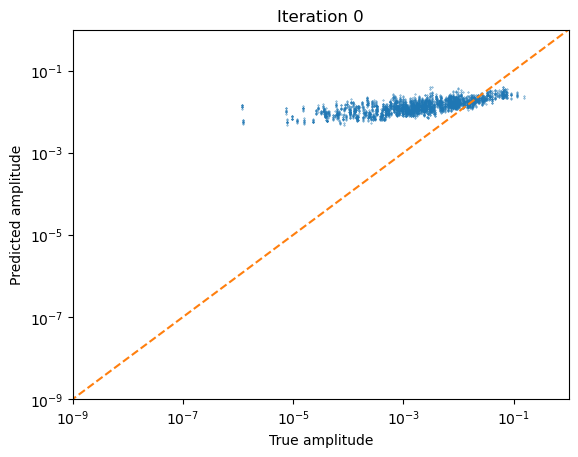

In [7]:
def update_plot(i):
    logger.info(f"Plotting iteration {i}")
    plt.clf()
    predicted_amplitudes = predicted_amplitudes_list[i].view(-1).detach().numpy()
    plt.scatter(true_amplitudes.detach().numpy(), predicted_amplitudes, s=0.1)
    plt.plot([0, 1], [0, 1], "--", color="C1")
    plt.xlim(1e-9, 1)
    plt.ylim(1e-9, 1)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("True amplitude")
    plt.ylabel("Predicted amplitude")
    plt.title(f"Iteration {i}")


fig, ax = plt.subplots()

ani = animation.FuncAnimation(fig, update_plot, frames=list(range(20)) + list(range(20, 800, 10)))
display(HTML(ani.to_jshtml()))
# ani.save("vmc_xor_kagome18.gif", writer="imagemagick", fps=5)

2023-09-19 22:32:49.254 | INFO     | __main__:update_plot:2 - Plotting iteration 0
2023-09-19 22:32:49.820 | INFO     | __main__:update_plot:2 - Plotting iteration 0
2023-09-19 22:32:50.594 | INFO     | __main__:update_plot:2 - Plotting iteration 1
2023-09-19 22:32:50.797 | INFO     | __main__:update_plot:2 - Plotting iteration 2
2023-09-19 22:32:50.999 | INFO     | __main__:update_plot:2 - Plotting iteration 3
2023-09-19 22:32:51.199 | INFO     | __main__:update_plot:2 - Plotting iteration 4
2023-09-19 22:32:51.400 | INFO     | __main__:update_plot:2 - Plotting iteration 5
2023-09-19 22:32:51.599 | INFO     | __main__:update_plot:2 - Plotting iteration 6
2023-09-19 22:32:51.799 | INFO     | __main__:update_plot:2 - Plotting iteration 7
2023-09-19 22:32:52.015 | INFO     | __main__:update_plot:2 - Plotting iteration 8
2023-09-19 22:32:52.215 | INFO     | __main__:update_plot:2 - Plotting iteration 9
2023-09-19 22:32:52.418 | INFO     | __main__:update_plot:2 - Plotting iteration 10
202

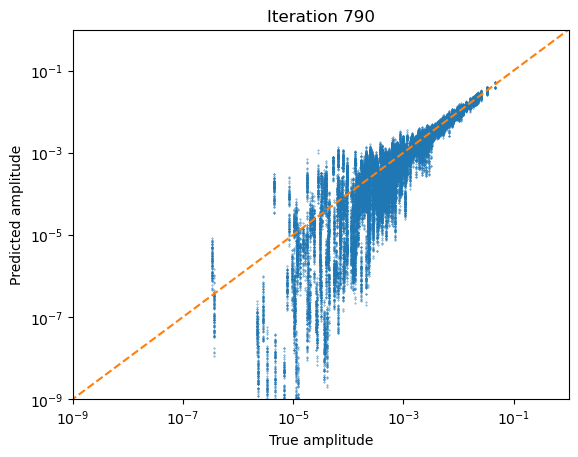

In [30]:
system.canonical_basis.states.shape

(48620,)

In [32]:
(eval_set == system.canonical_basis.states).all()

True

In [33]:
gs = np.asarray(system.get_ground_state_coeffs(system.basis.states), order='C')
np.allclose(system.hamiltonian @ gs, system.eigenvalues[0] * gs)

[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 240; batchedOperatorChunkSize: 203


True